In [1]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from scipy.stats import chi2_contingency
import math
from sklearn.metrics import roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

In [2]:
data_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DPF",
    "Age",
    "Class"
]
data_path = "data/pima-indians-diabetes.data.csv"

df_dataset = pd.read_csv(data_path, names=data_names)

df_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
def detect_physiological_errors(df, ranges):
    errors = {}

    for col, (min_val, max_val) in ranges.items():
        if col not in df.columns:
            continue

        # lọc giá trị ngoài khoảng hợp lệ
        mask = (df[col] < min_val) | (df[col] > max_val)
        problem_series = df.loc[mask, col]

        errors[col] = {
            "count": problem_series.shape[0],
            "min_actual": df[col].min(),
            "max_actual": df[col].max(),
            "problem_values": sorted(problem_series.unique().tolist())
        }

    return errors

physiological_ranges = {
    "Pregnancies": (0, 20),
    "Glucose": (20, 300),
    "BloodPressure": (40, 200),
    "BMI": (10, 80),
    "Age": (21, 100)
}
errors = detect_physiological_errors(df_dataset, physiological_ranges)

print("--- Dữ liệu lỗi phát hiện ---")
for col, info in errors.items():
    if info["count"] == 0:
        continue  # bỏ qua cột không có lỗi
    print(f"{col}: {info['count']} giá trị lỗi")
    print(f"    - Range thực tế: {info['min_actual']} - {info['max_actual']}")
    print(f"    - Giá trị có vấn đề: {info['problem_values']}")

--- Dữ liệu lỗi phát hiện ---
Glucose: 5 giá trị lỗi
    - Range thực tế: 0 - 199
    - Giá trị có vấn đề: [0]
BloodPressure: 39 giá trị lỗi
    - Range thực tế: 0 - 122
    - Giá trị có vấn đề: [0, 24, 30, 38]
BMI: 11 giá trị lỗi
    - Range thực tế: 0.0 - 67.1
    - Giá trị có vấn đề: [0.0]


In [4]:
rows_before = len(df_dataset)
df_clean = df_dataset.copy()

# ===== tạo mask tổng =====
invalid_mask_total = pd.Series(False, index=df_clean.index)

for col, (min_val, max_val) in physiological_ranges.items():
    if col in df_clean.columns:
        invalid_mask = (df_clean[col] < min_val) | (df_clean[col] > max_val)

        # cộng dồn mask
        invalid_mask_total |= invalid_mask

        # gán NaN
        df_clean.loc[invalid_mask, col] = np.nan

print("Đã đánh dấu NaN cho dữ liệu ngoài khoảng.")

Đã đánh dấu NaN cho dữ liệu ngoài khoảng.


In [5]:
# đếm số dòng có ít nhất 1 lỗi
rows_with_error = invalid_mask_total.sum()

# xóa các dòng có NaN ở các cột sinh lý
df_clean = df_clean.dropna(subset=physiological_ranges.keys())

rows_after = len(df_clean)

print("\n=== ĐỐI CHIẾU SỐ DÒNG ===")
print(f"Số dòng ban đầu: {rows_before}")
print(f"Số dòng có lỗi (unique rows): {rows_with_error}")
print(f"Số dòng sau khi làm sạch: {rows_after}")
print(f"Số dòng bị loại thực tế: {rows_before - rows_after}")


=== ĐỐI CHIẾU SỐ DÒNG ===
Số dòng ban đầu: 768
Số dòng có lỗi (unique rows): 48
Số dòng sau khi làm sạch: 720
Số dòng bị loại thực tế: 48


In [6]:
def handle_zero_values(df):
    zero_sensitive_columns = ['Insulin', 'SkinThickness']

    for col in zero_sensitive_columns:
        if col not in df.columns:
            continue

        zero_mask = df[col] == 0
        if zero_mask.any():
            print(f"Phát hiện {zero_mask.sum()} giá trị 0 trong {col}")

            median_val = df.loc[df[col] > 0, col].median()

            df.loc[zero_mask, col] = median_val

            print(f"    -> Đã thay thế bằng median: {median_val:.2f}")

    return df
df_clean = handle_zero_values(df_clean)


Phát hiện 332 giá trị 0 trong Insulin
    -> Đã thay thế bằng median: 126.00
Phát hiện 192 giá trị 0 trong SkinThickness
    -> Đã thay thế bằng median: 29.00


In [7]:
df_dataset = df_clean.copy()
print("\nDataset sau làm sạch:", df_dataset.shape)
display.display(df_dataset.tail(10))


Dataset sau làm sạch: (720, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Class
758,1.0,106.0,76.0,29,126,37.5,0.197,26.0,0
759,6.0,190.0,92.0,29,126,35.5,0.278,66.0,1
760,2.0,88.0,58.0,26,16,28.4,0.766,22.0,0
761,9.0,170.0,74.0,31,126,44.0,0.403,43.0,1
762,9.0,89.0,62.0,29,126,22.5,0.142,33.0,0
763,10.0,101.0,76.0,48,180,32.9,0.171,63.0,0
764,2.0,122.0,70.0,27,126,36.8,0.340,27.0,0
765,5.0,121.0,72.0,23,112,26.2,0.245,30.0,0
766,1.0,126.0,60.0,29,126,30.1,0.349,47.0,1
767,1.0,93.0,70.0,31,126,30.4,0.315,23.0,0


In [40]:
# ===== Lấy 2 đặc trưng =====
X = df_dataset[['Glucose', 'BMI']]

# ===== Chuẩn hóa dữ liệu (RẤT QUAN TRỌNG cho KMeans) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===== Áp dụng KMeans =====
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Gán nhãn cụm vào dataframe
df_dataset['Cluster'] = clusters

print("Số lượng bệnh nhân mỗi cụm:")
print(df_dataset['Cluster'].value_counts().sort_index())

Số lượng bệnh nhân mỗi cụm:
Cluster
0     90
1    245
2    149
3    236
Name: count, dtype: int64


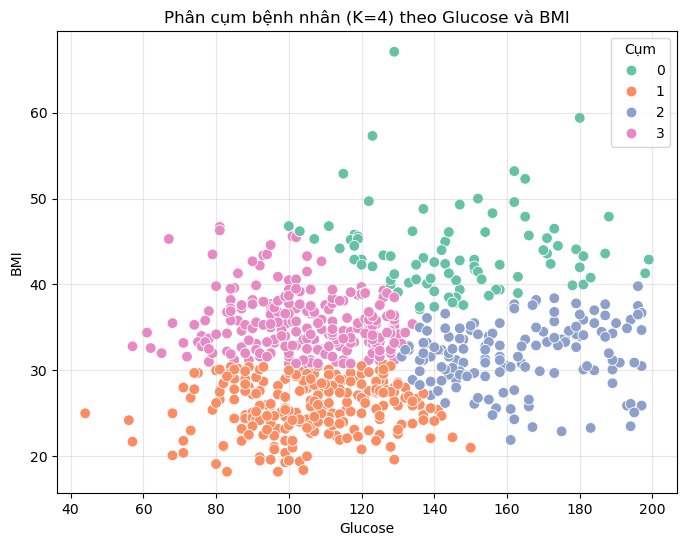

In [41]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x='Glucose',
    y='BMI',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title('Phân cụm bệnh nhân (K=4) theo Glucose và BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend(title='Cụm')
plt.grid(alpha=0.3)
plt.show()

In [42]:
def summarize_clusters(df):
    summary = []

    for cluster_id in sorted(df['Cluster'].unique()):
        group = df[df['Cluster'] == cluster_id]

        count = len(group)
        percent = count / len(df) * 100

        age_mean = group['Age'].mean()
        age_std = group['Age'].std()

        bmi_mean = group['BMI'].mean()
        bmi_std = group['BMI'].std()

        glu_mean = group['Glucose'].mean()
        glu_std = group['Glucose'].std()

        disease_rate = group['Class'].mean() * 100

        summary.append({
            'Cluster': cluster_id,
            'Count': count,
            'Percent': percent,
            'Age_mean': age_mean,
            'Age_std': age_std,
            'BMI_mean': bmi_mean,
            'BMI_std': bmi_std,
            'Glucose_mean': glu_mean,
            'Glucose_std': glu_std,
            'Disease_rate': disease_rate
        })

    return pd.DataFrame(summary)

cluster_summary = summarize_clusters(df_dataset)
cluster_summary

,Cluster,Count,Percent,Age_mean,Age_std,BMI_mean,BMI_std,Glucose_mean,Glucose_std,Disease_rate
0,0,90,12.500000,32.933333,10.133713,43.645556,4.971834,146.555556,22.263040,63.333333
1,1,245,34.027778,31.012245,11.959797,25.777143,3.053171,105.640816,18.290281,12.244898
2,2,149,20.694444,39.530201,12.862347,31.791946,3.701817,162.302013,19.140556,66.442953
3,3,236,32.777778,32.152542,10.086964,35.493644,3.347619,104.233051,16.576346,26.271186


In [43]:
for _, row in cluster_summary.iterrows():
    print(f"\nCỤM {int(row['Cluster'])} ({int(row['Count'])} bệnh nhân - {row['Percent']:.1f}%):")
    print(f"  • Tuổi trung bình: {row['Age_mean']:.1f} ± {row['Age_std']:.1f}")
    print(f"  • BMI trung bình: {row['BMI_mean']:.1f} ± {row['BMI_std']:.1f}")
    print(f"  • Glucose trung bình: {row['Glucose_mean']:.1f} ± {row['Glucose_std']:.1f}")
    print(f"  • Tỷ lệ mắc bệnh: {row['Disease_rate']:.1f}%")


CỤM 0 (90 bệnh nhân - 12.5%):
  • Tuổi trung bình: 32.9 ± 10.1
  • BMI trung bình: 43.6 ± 5.0
  • Glucose trung bình: 146.6 ± 22.3
  • Tỷ lệ mắc bệnh: 63.3%

CỤM 1 (245 bệnh nhân - 34.0%):
  • Tuổi trung bình: 31.0 ± 12.0
  • BMI trung bình: 25.8 ± 3.1
  • Glucose trung bình: 105.6 ± 18.3
  • Tỷ lệ mắc bệnh: 12.2%

CỤM 2 (149 bệnh nhân - 20.7%):
  • Tuổi trung bình: 39.5 ± 12.9
  • BMI trung bình: 31.8 ± 3.7
  • Glucose trung bình: 162.3 ± 19.1
  • Tỷ lệ mắc bệnh: 66.4%

CỤM 3 (236 bệnh nhân - 32.8%):
  • Tuổi trung bình: 32.2 ± 10.1
  • BMI trung bình: 35.5 ± 3.3
  • Glucose trung bình: 104.2 ± 16.6
  • Tỷ lệ mắc bệnh: 26.3%


In [44]:
# Lấy 2 biến
X_ag = df_dataset[['Age', 'Glucose']]

# Chuẩn hóa (rất nên làm)
scaler_ag = StandardScaler()
X_ag_scaled = scaler_ag.fit_transform(X_ag)

# KMeans k=4
kmeans_ag = KMeans(n_clusters=4, random_state=42, n_init=10)
df_dataset['Cluster_AG'] = kmeans_ag.fit_predict(X_ag_scaled)

In [45]:
def summarize_clusters_ag(df):
    summary = []

    for cluster_id in sorted(df['Cluster_AG'].unique()):
        group = df[df['Cluster_AG'] == cluster_id]

        count = len(group)
        percent = count / len(df) * 100

        age_mean = group['Age'].mean()
        age_std = group['Age'].std()

        glu_mean = group['Glucose'].mean()
        glu_std = group['Glucose'].std()

        disease_rate = group['Class'].mean() * 100

        summary.append({
            'Cluster': cluster_id,
            'Count': count,
            'Percent (%)': percent,
            'Age_mean': age_mean,
            'Age_std': age_std,
            'Glucose_mean': glu_mean,
            'Glucose_std': glu_std,
            'Disease_rate (%)': disease_rate
        })

    return pd.DataFrame(summary)

cluster_ag_summary = summarize_clusters_ag(df_dataset)
cluster_ag_summary.round(2)

,Cluster,Count,Percent (%),Age_mean,Age_std,Glucose_mean,Glucose_std,Disease_rate (%)
0,0,355,49.31,25.66,3.89,104.35,15.83,15.49
1,1,131,18.19,44.67,7.02,105.00,18.94,38.93
2,2,153,21.25,30.31,6.57,159.58,18.98,60.13
3,3,81,11.25,54.80,7.93,156.01,20.20,61.73


In [46]:
for _, row in cluster_ag_summary.iterrows():
    print(f"\nCỤM {int(row['Cluster'])} ({int(row['Count'])} bệnh nhân - {row['Percent (%)']:.1f}%):")
    print(f"  • Tuổi trung bình: {row['Age_mean']:.1f} ± {row['Age_std']:.1f}")
    print(f"  • Glucose trung bình: {row['Glucose_mean']:.1f} ± {row['Glucose_std']:.1f}")
    print(f"  • Tỷ lệ mắc bệnh: {row['Disease_rate (%)']:.1f}%")


CỤM 0 (355 bệnh nhân - 49.3%):
  • Tuổi trung bình: 25.7 ± 3.9
  • Glucose trung bình: 104.4 ± 15.8
  • Tỷ lệ mắc bệnh: 15.5%

CỤM 1 (131 bệnh nhân - 18.2%):
  • Tuổi trung bình: 44.7 ± 7.0
  • Glucose trung bình: 105.0 ± 18.9
  • Tỷ lệ mắc bệnh: 38.9%

CỤM 2 (153 bệnh nhân - 21.2%):
  • Tuổi trung bình: 30.3 ± 6.6
  • Glucose trung bình: 159.6 ± 19.0
  • Tỷ lệ mắc bệnh: 60.1%

CỤM 3 (81 bệnh nhân - 11.2%):
  • Tuổi trung bình: 54.8 ± 7.9
  • Glucose trung bình: 156.0 ± 20.2
  • Tỷ lệ mắc bệnh: 61.7%


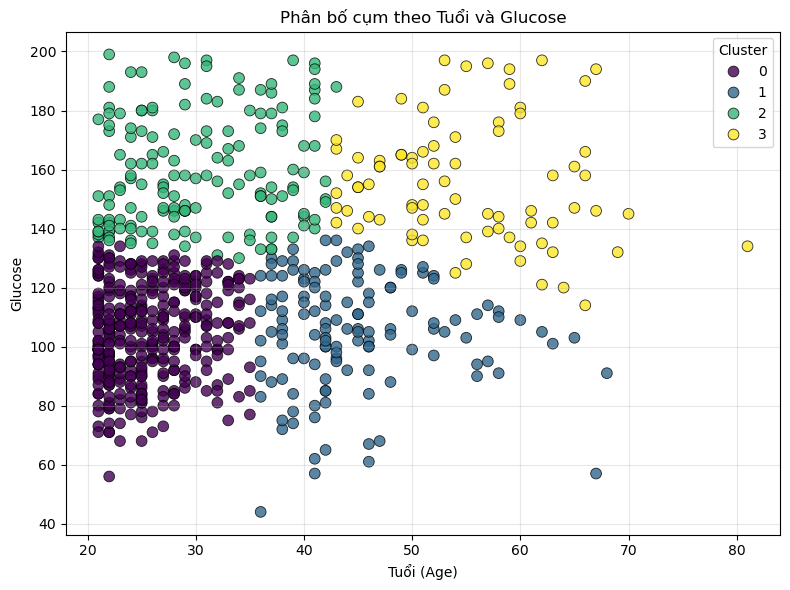

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x='Age',
    y='Glucose',
    hue='Cluster_AG',
    palette='viridis',
    s=60,
    alpha=0.8,
    edgecolor='k'
)

plt.title('Phân bố cụm theo Tuổi và Glucose')
plt.xlabel('Tuổi (Age)')
plt.ylabel('Glucose')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [48]:
# Lấy 2 biến
X_bg = df_dataset[['BMI', 'Glucose']]

# Chuẩn hóa
scaler_bg = StandardScaler()
X_bg_scaled = scaler_bg.fit_transform(X_bg)

# KMeans k=4
kmeans_bg = KMeans(n_clusters=4, random_state=42, n_init=10)
df_dataset['Cluster_BG'] = kmeans_bg.fit_predict(X_bg_scaled)


In [49]:
def summarize_clusters_bg(df):
    summary = []

    for cluster_id in sorted(df['Cluster_BG'].unique()):
        group = df[df['Cluster_BG'] == cluster_id]

        count = len(group)
        percent = count / len(df) * 100

        bmi_mean = group['BMI'].mean()
        bmi_std = group['BMI'].std()

        glu_mean = group['Glucose'].mean()
        glu_std = group['Glucose'].std()

        disease_rate = group['Class'].mean() * 100

        summary.append({
            'Cluster': cluster_id,
            'Count': count,
            'Percent (%)': percent,
            'BMI_mean': bmi_mean,
            'BMI_std': bmi_std,
            'Glucose_mean': glu_mean,
            'Glucose_std': glu_std,
            'Disease_rate (%)': disease_rate
        })

    return pd.DataFrame(summary)

cluster_bg_summary = summarize_clusters_bg(df_dataset)
cluster_bg_summary.round(2)


,Cluster,Count,Percent (%),BMI_mean,BMI_std,Glucose_mean,Glucose_std,Disease_rate (%)
0,0,90,12.50,43.65,4.97,146.56,22.26,63.33
1,1,245,34.03,25.78,3.05,105.64,18.29,12.24
2,2,149,20.69,31.79,3.70,162.30,19.14,66.44
3,3,236,32.78,35.49,3.35,104.23,16.58,26.27


In [50]:
for _, row in cluster_bg_summary.iterrows():
    print(f"\nCỤM {int(row['Cluster'])} ({int(row['Count'])} bệnh nhân - {row['Percent (%)']:.1f}%):")
    print(f"  • BMI trung bình: {row['BMI_mean']:.1f} ± {row['BMI_std']:.1f}")
    print(f"  • Glucose trung bình: {row['Glucose_mean']:.1f} ± {row['Glucose_std']:.1f}")
    print(f"  • Tỷ lệ mắc bệnh: {row['Disease_rate (%)']:.1f}%")



CỤM 0 (90 bệnh nhân - 12.5%):
  • BMI trung bình: 43.6 ± 5.0
  • Glucose trung bình: 146.6 ± 22.3
  • Tỷ lệ mắc bệnh: 63.3%

CỤM 1 (245 bệnh nhân - 34.0%):
  • BMI trung bình: 25.8 ± 3.1
  • Glucose trung bình: 105.6 ± 18.3
  • Tỷ lệ mắc bệnh: 12.2%

CỤM 2 (149 bệnh nhân - 20.7%):
  • BMI trung bình: 31.8 ± 3.7
  • Glucose trung bình: 162.3 ± 19.1
  • Tỷ lệ mắc bệnh: 66.4%

CỤM 3 (236 bệnh nhân - 32.8%):
  • BMI trung bình: 35.5 ± 3.3
  • Glucose trung bình: 104.2 ± 16.6
  • Tỷ lệ mắc bệnh: 26.3%


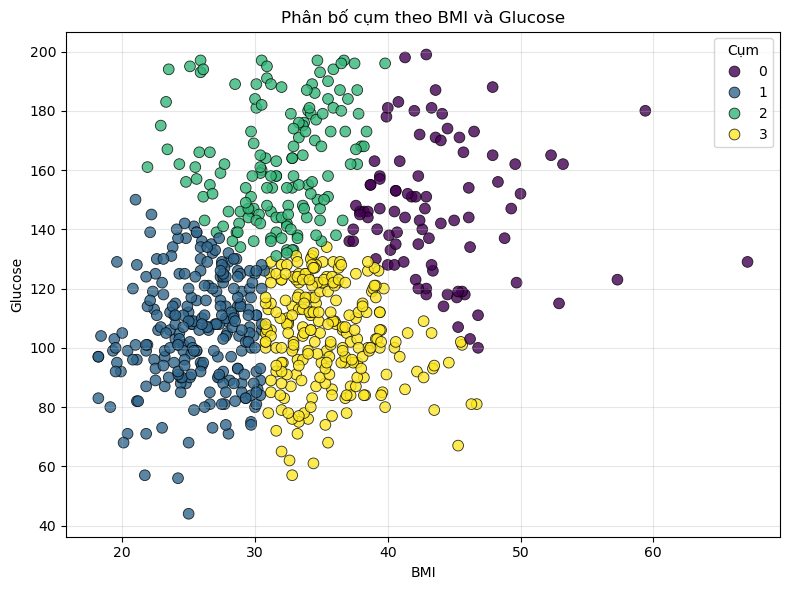

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x='BMI',
    y='Glucose',
    hue='Cluster_BG',
    palette='viridis',
    s=60,
    alpha=0.8,
    edgecolor='k'
)

plt.title('Phân bố cụm theo BMI và Glucose')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.legend(title='Cụm')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [52]:
# Tính tỷ lệ mắc bệnh theo cụm
disease_by_cluster = (
    df_dataset
    .groupby('Cluster_BG')['Class']
    .mean()
    .reset_index()
)

disease_by_cluster['Disease_rate (%)'] = disease_by_cluster['Class'] * 100
disease_by_cluster

,Cluster_BG,Class,Disease_rate (%)
0,0,0.633333,63.333333
1,1,0.122449,12.244898
2,2,0.664430,66.442953
3,3,0.262712,26.271186


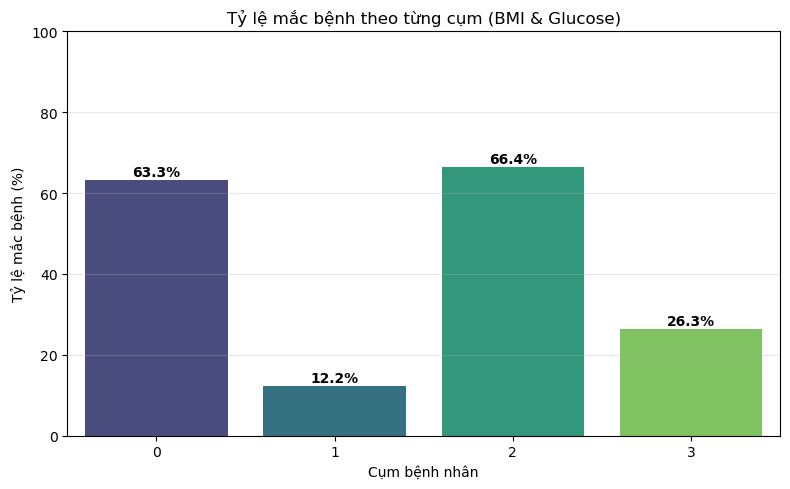

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=disease_by_cluster,
    x='Cluster_BG',
    y='Disease_rate (%)',
    palette='viridis'
)

# Hiện số trên đầu cột
for i, v in enumerate(disease_by_cluster['Disease_rate (%)']):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.title('Tỷ lệ mắc bệnh theo từng cụm (BMI & Glucose)')
plt.xlabel('Cụm bệnh nhân')
plt.ylabel('Tỷ lệ mắc bệnh (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

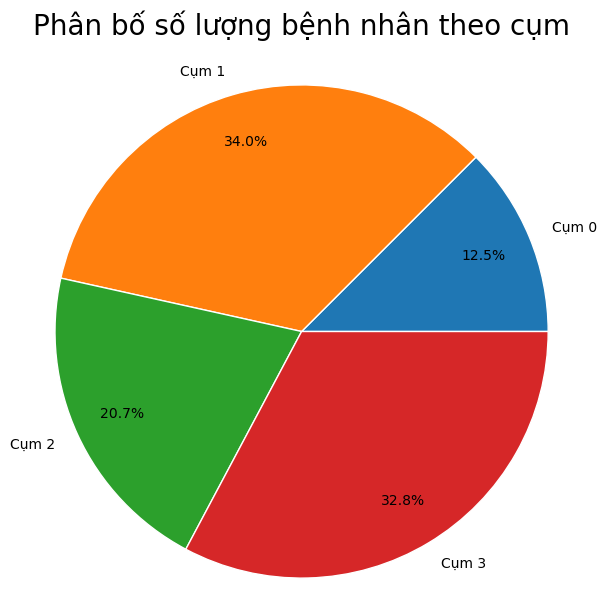

In [54]:
# Đếm số bệnh nhân mỗi cụm
cluster_counts = df_dataset['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(
    cluster_counts,
    labels=[f'Cụm {i}' for i in cluster_counts.index],
    autopct='%1.1f%%',
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Phân bố số lượng bệnh nhân theo cụm', fontsize=20, pad=20)
plt.axis('equal')
plt.show()


In [55]:
data_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DPF",
    "Age"
]

# ===== Tạo dataframe phục vụ OR =====
df_or = df_dataset[data_names + ['Cluster', 'Class']].copy()

print("Kiểm tra dữ liệu OR:")
df_or.head()


Kiểm tra dữ liệu OR:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Cluster,Class
0,6.0,148.0,72.0,35,126,33.6,0.627,50.0,2,1
1,1.0,85.0,66.0,29,126,26.6,0.351,31.0,1,0
2,8.0,183.0,64.0,29,126,23.3,0.672,32.0,2,1
3,1.0,89.0,66.0,23,94,28.1,0.167,21.0,1,0
4,0.0,137.0,40.0,35,168,43.1,2.288,33.0,0,1


In [56]:
or_table = (
    df_or
    .groupby('Cluster')['Class']
    .agg(['count', 'sum'])
    .reset_index()
)

# đổi tên cho rõ nghĩa
or_table = or_table.rename(columns={
    'count': 'total',
    'sum': 'disease_cases'
})

# số không mắc bệnh
or_table['non_disease'] = or_table['total'] - or_table['disease_cases']

# odds
or_table['odds'] = or_table['disease_cases'] / or_table['non_disease']

print("\nBảng chuẩn bị tính Odds Ratio:")
or_table



Bảng chuẩn bị tính Odds Ratio:


,Cluster,total,disease_cases,non_disease,odds
0,0,90,57,33,1.727273
1,1,245,30,215,0.139535
2,2,149,99,50,1.980000
3,3,236,62,174,0.356322


In [57]:
def compute_odds_ratio(table, ref_cluster=1):
    """
    table: dataframe từ or_table
    ref_cluster: cụm tham chiếu
    """
    ref = table[table['Cluster'] == ref_cluster].iloc[0]
    c, d = ref['disease_cases'], ref['non_disease']

    results = []

    for _, row in table.iterrows():
        a, b = row['disease_cases'], row['non_disease']

        or_value = (a / b) / (c / d)

        results.append({
            'Cluster': row['Cluster'],
            'Odds': row['odds'],
            'Odds_Ratio_vs_ref': or_value
        })

    return pd.DataFrame(results)

# ===== Tính OR (mặc định so với cụm 1) =====
or_results = compute_odds_ratio(or_table, ref_cluster=1)

print("\nOdds Ratio theo cụm:")
or_results


Odds Ratio theo cụm:


,Cluster,Odds,Odds_Ratio_vs_ref
0,0.0,1.727273,12.378788
1,1.0,0.139535,1.000000
2,2.0,1.980000,14.190000
3,3.0,0.356322,2.553640


In [58]:
# ===== Tạo nhị phân theo median để tính OR từng biến =====
def prepare_feature_or(df, feature):
    median_val = df[feature].median()
    df_tmp = df.copy()
    df_tmp['high_risk'] = (df_tmp[feature] >= median_val).astype(int)

    table = pd.crosstab(df_tmp['high_risk'], df_tmp['Class'])
    return feature, median_val, table

# chạy cho tất cả biến
feature_tables = []

for col in data_names:
    feat, med, tab = prepare_feature_or(df_or, col)
    feature_tables.append((feat, med, tab))

# xem thử
for feat, med, tab in feature_tables[:3]:
    print(f"\n=== {feat} (median={med:.2f}) ===")
    print(tab)


=== Pregnancies (median=3.00) ===
Class        0    1
high_risk          
0          245   77
1          227  171

=== Glucose (median=117.00) ===
Class        0    1
high_risk          
0          296   57
1          176  191

=== BloodPressure (median=72.00) ===
Class        0    1
high_risk          
0          241   91
1          231  157


In [59]:
# chọn cluster tham chiếu (ở đây là 1)
ref_cluster = 1
ref_odds = or_table.loc[or_table['Cluster'] == ref_cluster, 'odds'].values[0]

# tính Odds Ratio
or_table['OR_vs_cluster1'] = or_table['odds'] / ref_odds

# làm đẹp bảng
or_result = or_table[['Cluster', 'total', 'disease_cases', 'odds', 'OR_vs_cluster1']]

print("\nBẢNG ODDS RATIO (so với Cluster 1):")
or_result



BẢNG ODDS RATIO (so với Cluster 1):


,Cluster,total,disease_cases,odds,OR_vs_cluster1
0,0,90,57,1.727273,12.378788
1,1,245,30,0.139535,1.000000
2,2,149,99,1.980000,14.190000
3,3,236,62,0.356322,2.553640


In [60]:
# ===== Chọn các ngưỡng nguy cơ (bạn có thể chỉnh) =====
thresholds = {
    "Pregnancies": 4,
    "Glucose": 126,
    "BloodPressure": 90,
    "SkinThickness": 30,
    "Insulin": 166,
    "BMI": 35,
    "DPF": 0.5,
    "Age": 45
}

results = []

for feature in data_names:
    thr = thresholds[feature]

    # tạo biến nhị phân nguy cơ
    risk_col = df_dataset[feature] >= thr

    # bảng 2x2
    a = ((risk_col) & (df_dataset['Class'] == 1)).sum()
    b = ((risk_col) & (df_dataset['Class'] == 0)).sum()
    c = ((~risk_col) & (df_dataset['Class'] == 1)).sum()
    d = ((~risk_col) & (df_dataset['Class'] == 0)).sum()

    # tránh chia cho 0 (Haldane correction)
    if 0 in [a, b, c, d]:
        a += 0.5
        b += 0.5
        c += 0.5
        d += 0.5

    # ===== Odds Ratio =====
    OR = (a * d) / (b * c)

    # ===== 95% CI =====
    se = math.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low = math.exp(math.log(OR) - 1.96 * se)
    ci_high = math.exp(math.log(OR) + 1.96 * se)

    # ===== p-value (chi-square) =====
    table = [[a, b], [c, d]]
    _, p_value, _, _ = chi2_contingency(table)

    # ===== phân loại theo OR =====
    if OR < 1:
        classification = "Rất thấp"
    elif OR < 2:
        classification = "Thấp"
    elif OR < 3:
        classification = "Vừa"
    elif OR < 4:
        classification = "Cao"
    else:
        classification = "Rất cao"

    results.append([
    feature,
    thr,
    round(OR, 2),                         # OR làm tròn 2 chữ số
    f"({ci_low:.2f}–{ci_high:.2f})",      # CI có ngoặc đơn
    round(p_value, 2),                    # p-value làm tròn
    classification
    ])

# ===== tạo bảng =====
or_risk_table = pd.DataFrame(results, columns=[
    "Yếu tố nguy cơ",
    "Ngưỡng >=",
    "OR",
    "95% CI",
    "P-value",
    "Phân loại"
])

or_risk_table


,Yếu tố nguy cơ,Ngưỡng >=,OR,95% CI,P-value,Phân loại
0,Pregnancies,4.0,2.26,(1.65–3.10),0.00,Vừa
1,Glucose,126.0,5.79,(4.14–8.10),0.00,Rất cao
2,BloodPressure,90.0,1.81,(1.06–3.09),0.04,Thấp
3,SkinThickness,30.0,1.87,(1.36–2.57),0.00,Thấp
4,Insulin,166.0,2.46,(1.68–3.60),0.00,Vừa
5,BMI,35.0,2.10,(1.52–2.89),0.00,Vừa
6,DPF,0.5,2.14,(1.56–2.94),0.00,Vừa
7,Age,45.0,2.22,(1.51–3.27),0.00,Vừa


In [61]:
results_score = []

for feature in data_names:
    if feature == "Class":
        continue

    thr = thresholds[feature]

    # biến nguy cơ
    risk_col = df_dataset[feature] >= thr
    outcome = df_dataset["Class"]

    # bảng 2x2
    table = pd.crosstab(risk_col, outcome)

    if table.shape != (2, 2):
        continue

    a, b, c, d = table.iloc[1,1], table.iloc[1,0], table.iloc[0,1], table.iloc[0,0]

    # tính OR
    OR = (a*d) / (b*c) if b*c != 0 else np.nan

    # CI 95%
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low = np.exp(np.log(OR) - 1.96*se)
    ci_high = np.exp(np.log(OR) + 1.96*se)

    # ===== phân loại =====
    if OR < 1:
        classification = "Rất thấp"
        score = 0
    elif OR < 2:
        classification = "Thấp"
        score = 1
    elif OR < 3:
        classification = "Vừa"
        score = 2
    elif OR < 4:
        classification = "Cao"
        score = 3
    else:
        classification = "Rất cao"
        score = 4

    results_score.append([
        feature,
        thr,
        f"{OR:.2f}",
        f"({ci_low:.2f}–{ci_high:.2f})",
        classification,
        score
    ])

# tạo dataframe
score_table = pd.DataFrame(results_score, columns=[
    "Yếu tố nguy cơ",
    "Ngưỡng >=",
    "OR",
    "95% CI",
    "Phân loại",
    "Điểm"
])

score_table


,Yếu tố nguy cơ,Ngưỡng >=,OR,95% CI,Phân loại,Điểm
0,Pregnancies,4.0,2.26,(1.65–3.10),Vừa,2
1,Glucose,126.0,5.79,(4.14–8.10),Rất cao,4
2,BloodPressure,90.0,1.81,(1.06–3.09),Thấp,1
3,SkinThickness,30.0,1.87,(1.36–2.57),Thấp,1
4,Insulin,166.0,2.46,(1.68–3.60),Vừa,2
5,BMI,35.0,2.10,(1.52–2.89),Vừa,2
6,DPF,0.5,2.14,(1.56–2.94),Vừa,2
7,Age,45.0,2.22,(1.51–3.27),Vừa,2


In [62]:
# khởi tạo điểm
df_dataset["risk_score"] = 0
# cộng điểm theo từng yếu tố nguy cơ
for _, row in score_table.iterrows():
    feature = row["Yếu tố nguy cơ"]
    thr = row["Ngưỡng >="]
    pts = row["Điểm"]

    df_dataset["risk_score"] += (df_dataset[feature] >= thr) * pts

df_dataset["RiskGroup"] = pd.cut(
    df_dataset["risk_score"],
    bins=[-1, 3, 6, 9, float("inf")],
    labels=[
        "Nguy cơ thấp (0-3)",
        "Nguy cơ vừa (4-6)",
        "Nguy cơ cao (7-9)",
        "Nguy cơ rất cao (>=10)"
    ]
)
risk_summary = (
    df_dataset
    .groupby("RiskGroup")["Class"]
    .agg(
        so_benh_nhan="count",
        ti_le_mac_benh=lambda x: round(x.mean()*100, 1)
    )
    .reset_index()
    .rename(columns={
        "RiskGroup": "Mức độ nguy cơ",
        "ti_le_mac_benh": "Tỉ lệ mắc bệnh (%)",
        "so_benh_nhan": "Số bệnh nhân"
    })
)
risk_summary

,Mức độ nguy cơ,Số bệnh nhân,Tỉ lệ mắc bệnh (%)
0,Nguy cơ thấp (0-3),285,12.3
1,Nguy cơ vừa (4-6),189,31.2
2,Nguy cơ cao (7-9),158,60.1
3,Nguy cơ rất cao (>=10),88,67.0


In [63]:
roc_rows = []

features = ["Glucose", "BMI", "Age", "risk_score"]

y_true = df_dataset["Class"]

for feature in features:
    y_score = df_dataset[feature]

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    # tìm ngưỡng tối ưu theo Youden Index
    youden_index = tpr - fpr
    best_idx = np.argmax(youden_index)

    optimal_threshold = thresholds[best_idx]
    sensitivity = tpr[best_idx]
    specificity = 1 - fpr[best_idx]

    roc_rows.append({
        "Biến": feature if feature != "risk_score" else "RiskScore",
        "Ngưỡng tối ưu": round(optimal_threshold, 1),
        "AUC": round(roc_auc, 2),
        "Độ nhạy": round(sensitivity * 100, 1),
        "Độ đặc hiệu": round(specificity * 100, 1)
    })
roc_table = pd.DataFrame(roc_rows)
roc_table["Độ nhạy"] = roc_table["Độ nhạy"].astype(str) + "%"
roc_table["Độ đặc hiệu"] = roc_table["Độ đặc hiệu"].astype(str) + "%"
roc_table


,Biến,Ngưỡng tối ưu,AUC,Độ nhạy,Độ đặc hiệu
0,Glucose,128.0,0.79,65.3%,77.3%
1,BMI,30.3,0.68,80.2%,49.6%
2,Age,29.0,0.69,74.2%,58.7%
3,RiskScore,7.0,0.77,62.1%,80.5%


In [64]:
# ===== Tạo bảng giống báo cáo =====

glucose_thresholds = [100, 110, 120, 130, 140, 150, 160]

y_true = df_dataset["Class"]

rows = []

for thr in glucose_thresholds:
    y_pred = (df_dataset["Glucose"] >= thr).astype(int)

    TP = ((y_pred == 1) & (y_true == 1)).sum()
    TN = ((y_pred == 0) & (y_true == 0)).sum()
    FP = ((y_pred == 1) & (y_true == 0)).sum()
    FN = ((y_pred == 0) & (y_true == 1)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) else 0
    specificity = TN / (TN + FP) if (TN + FP) else 0
    ppv = TP / (TP + FP) if (TP + FP) else 0
    npv = TN / (TN + FN) if (TN + FN) else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    rows.append([
        thr,
        sensitivity*100,
        specificity*100,
        ppv*100,
        npv*100,
        accuracy*100
    ])

# ===== IN BẢNG ĐẸP =====

print("-"*78)
print(f"{'Ngưỡng Glucose':<19}{'Độ nhạy':>10}{'Độ đặc hiệu':>15}{'PPV':>8}{'NPV':>9}{'Độ chính xác':>17}")
print("-"*78)

for r in rows:
    print(f">={r[0]:<11} mg/dL"
          f"{r[1]:>8.1f} %"
          f"{r[2]:>12.1f} %"
          f"{r[3]:>8.1f} %"
          f"{r[4]:>8.1f} %"
          f"{r[5]:>12.1f} %")

print("-"*78)

------------------------------------------------------------------------------
Ngưỡng Glucose        Độ nhạy    Độ đặc hiệu     PPV      NPV     Độ chính xác
------------------------------------------------------------------------------
>=100         mg/dL    94.8 %        35.2 %    43.4 %    92.7 %        55.7 %
>=110         mg/dL    83.9 %        53.2 %    48.5 %    86.3 %        63.7 %
>=120         mg/dL    74.2 %        66.1 %    53.5 %    83.0 %        68.9 %
>=130         mg/dL    60.9 %        79.9 %    61.4 %    79.5 %        73.3 %
>=140         mg/dL    51.6 %        86.9 %    67.4 %    77.4 %        74.7 %
>=150         mg/dL    41.5 %        92.2 %    73.6 %    75.0 %        74.7 %
>=160         mg/dL    32.7 %        96.2 %    81.8 %    73.1 %        74.3 %
------------------------------------------------------------------------------


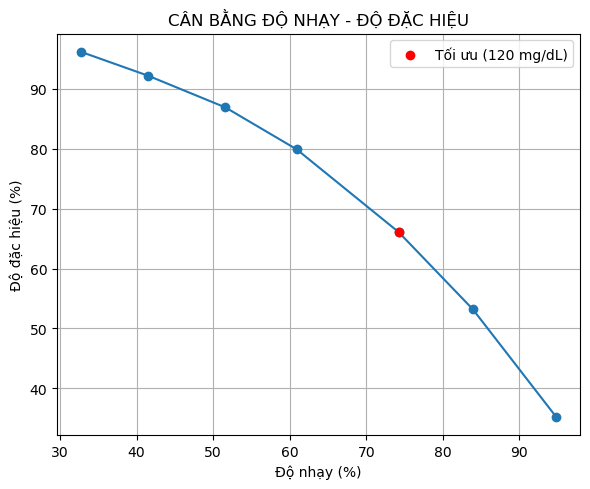

In [65]:
thresholds = [100,110,120,130,140,150,160]

sensitivity = [94.8,83.9,74.2,60.9,51.6,41.5,32.7]
specificity = [35.2,53.2,66.1,79.9,86.9,92.2,96.2]

# ===== TÌM ĐIỂM CÂN BẰNG =====
diff = [abs(s - sp) for s, sp in zip(sensitivity, specificity)]
best_idx = diff.index(min(diff))

plt.figure(figsize=(6,5))

plt.plot(sensitivity, specificity, marker='o')
plt.scatter(sensitivity[best_idx], specificity[best_idx],
            color='red', zorder=5,
            label=f'Tối ưu ({thresholds[best_idx]} mg/dL)')

plt.title('CÂN BẰNG ĐỘ NHẠY - ĐỘ ĐẶC HIỆU')
plt.xlabel('Độ nhạy (%)')
plt.ylabel('Độ đặc hiệu (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

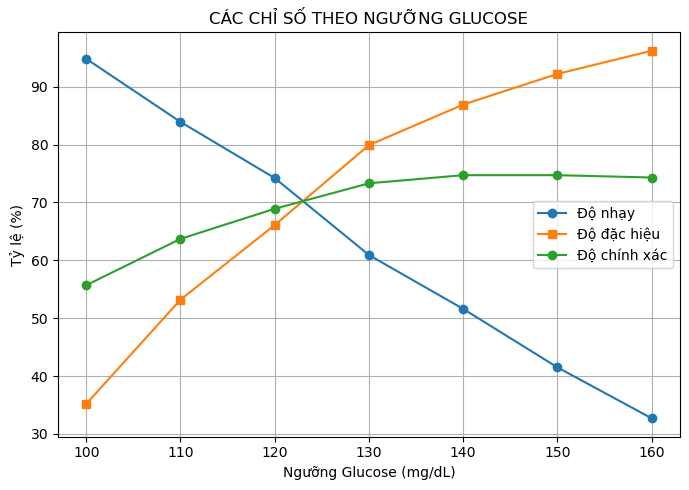

In [66]:
thresholds = [100,110,120,130,140,150,160]

sensitivity = [94.8,83.9,74.2,60.9,51.6,41.5,32.7]
specificity = [35.2,53.2,66.1,79.9,86.9,92.2,96.2]
accuracy    = [55.7,63.7,68.9,73.3,74.7,74.7,74.3]

plt.figure(figsize=(7,5))

plt.plot(thresholds, sensitivity, marker='o', label='Độ nhạy')
plt.plot(thresholds, specificity, marker='s', label='Độ đặc hiệu')
plt.plot(thresholds, accuracy, marker='o', label='Độ chính xác')

plt.title('CÁC CHỈ SỐ THEO NGƯỠNG GLUCOSE')
plt.xlabel('Ngưỡng Glucose (mg/dL)')
plt.ylabel('Tỷ lệ (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Bổ sung chân nhân danh phầm tình ao

#### Sơ đồ 1

In [67]:
num_df1 = df_dataset[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DPF','Age','Class']]

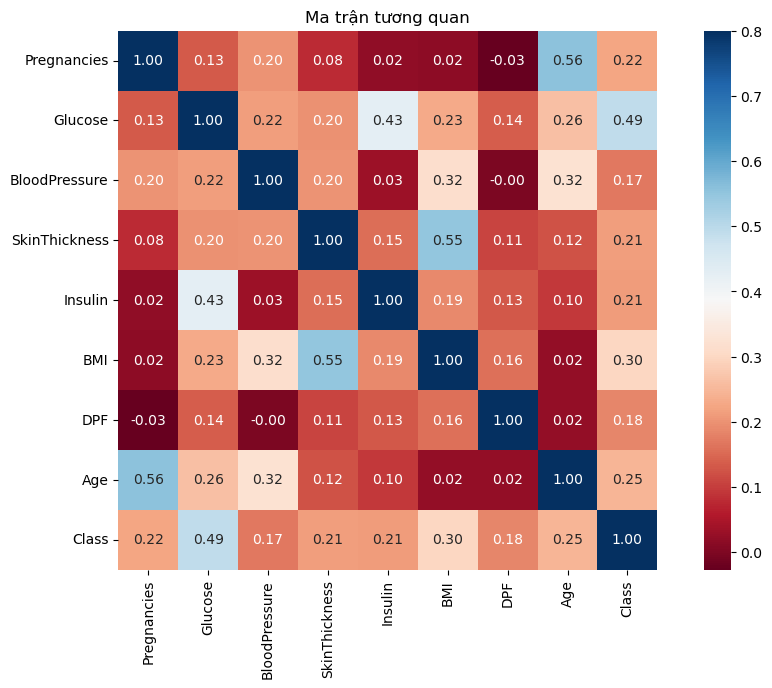

In [68]:
#correlation matrix
corrmat = num_df1.corr()
f, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(corrmat,annot = True,fmt='.2f', annot_kws={'size': 10},  vmax=.8, square=True,cmap="RdBu");
ax.set_title("Ma trận tương quan")
plt.savefig(
    "correlation_matrix.png",   # tên file
    dpi=300,                    # chuẩn in đồ án / luận văn
    bbox_inches="tight"
)

# Ma trận từ Glucose

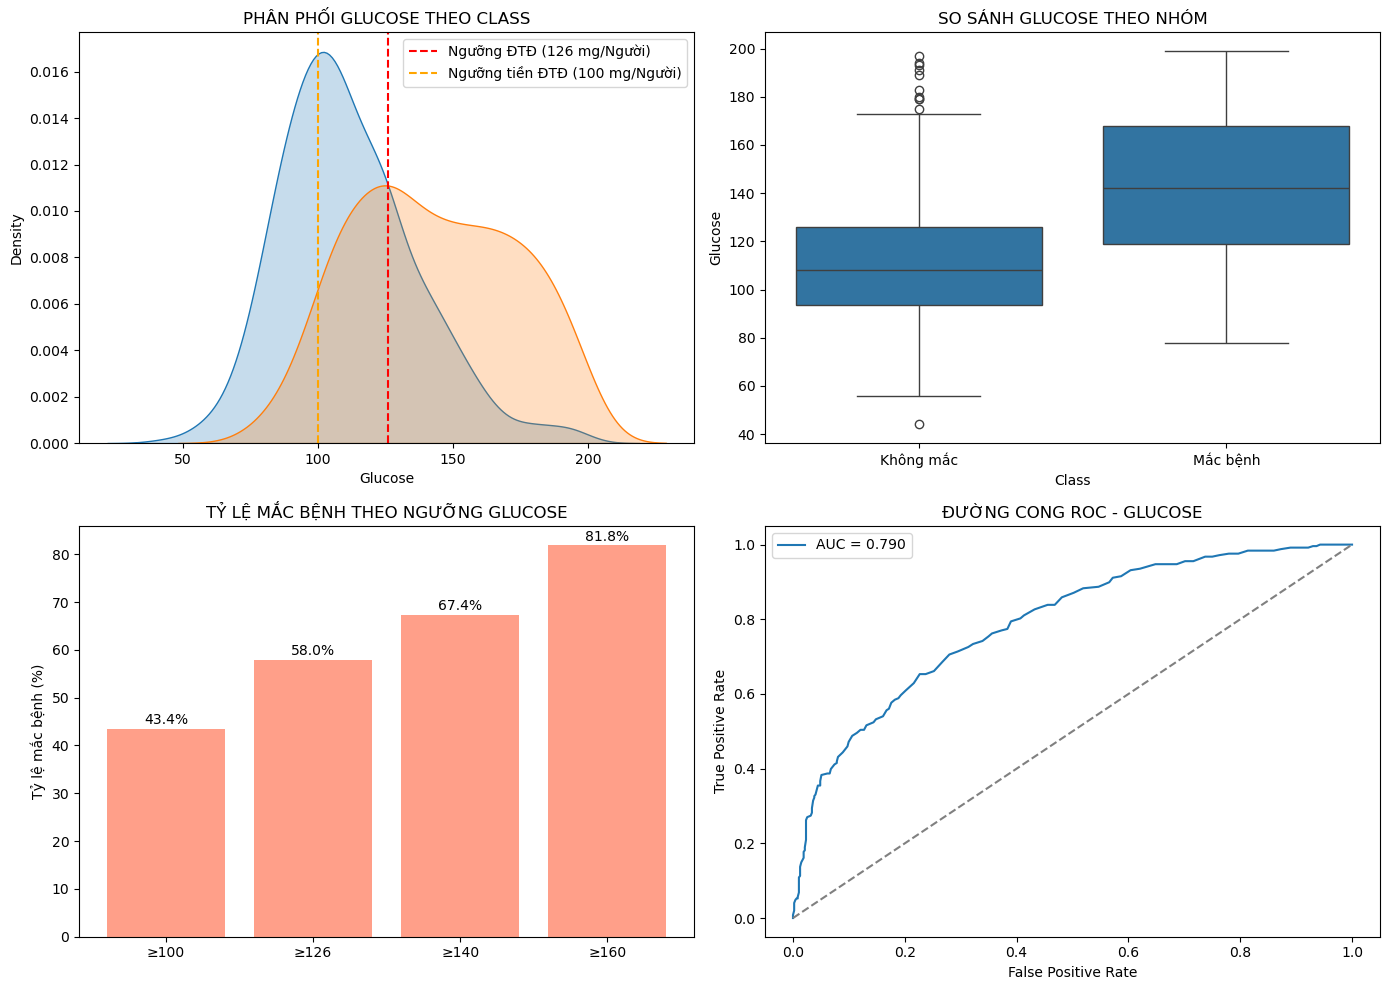

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

## Hình 1
sns.kdeplot(
    data=df_dataset[df_dataset["Class"] == 0],
    x="Glucose",
    fill=True,
    ax=axes[0, 0]
)

sns.kdeplot(
    data=df_dataset[df_dataset["Class"] == 1],
    x="Glucose",
    fill=True,
    ax=axes[0, 0]
)

# Ngưỡng y học
axes[0, 0].axvline(126, linestyle="--", color="red", label="Ngưỡng ĐTĐ (126 mg/Người)")
axes[0, 0].axvline(100, linestyle="--", color="orange", label="Ngưỡng tiền ĐTĐ (100 mg/Người)")

axes[0, 0].set_title("PHÂN PHỐI GLUCOSE THEO CLASS")
axes[0, 0].set_xlabel("Glucose")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()


##
sns.boxplot(
    data=df_dataset,
    x="Class",
    y="Glucose",
    ax=axes[0, 1]
)

axes[0, 1].set_title("SO SÁNH GLUCOSE THEO NHÓM")
axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Glucose")
axes[0, 1].set_xticklabels(["Không mắc", "Mắc bệnh"])

##

thresholds = [100, 126, 140, 160]
rates = []

for t in thresholds:
    rate = df_dataset[df_dataset["Glucose"] >= t]["Class"].mean() * 100
    rates.append(rate)

axes[1, 0].bar(
    [f"≥{t}" for t in thresholds],
    rates,
    color="#ff9f89"
)

for i, v in enumerate(rates):
    axes[1, 0].text(i, v + 1, f"{v:.1f}%", ha="center")

axes[1, 0].set_title("TỶ LỆ MẮC BỆNH THEO NGƯỠNG GLUCOSE")
axes[1, 0].set_ylabel("Tỷ lệ mắc bệnh (%)")

##

y_true = df_dataset["Class"]
y_score = df_dataset["Glucose"]

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

axes[1, 1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")

axes[1, 1].set_title("ĐƯỜNG CONG ROC - GLUCOSE")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend()


##
plt.tight_layout()
plt.savefig(
    "hinh_5_2_glucose_outcome.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



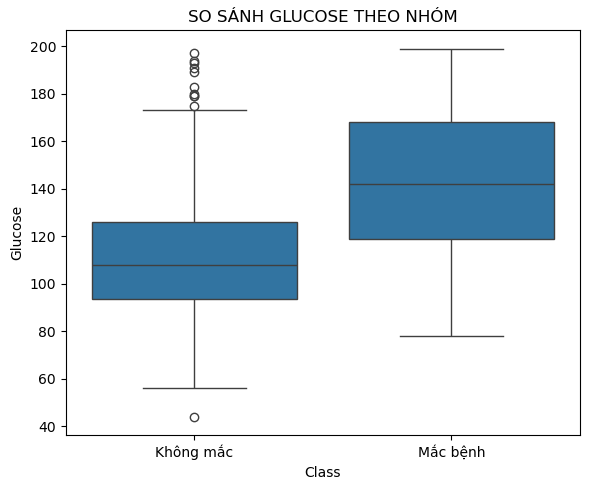

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_dataset,
    x="Class",
    y="Glucose"
)

plt.title("SO SÁNH GLUCOSE THEO NHÓM")
plt.xlabel("Class")
plt.ylabel("Glucose")
plt.xticks([0, 1], ["Không mắc", "Mắc bệnh"])

plt.tight_layout()
plt.savefig(
    "hinh_boxplot_glucose.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig("hinh2.png",dpi = 300)
plt.show()

In [70]:
from scipy.stats import pearsonr

# Lấy 2 biến cần phân tích
x = df_dataset["Glucose"]
y = df_dataset["Class"]

# Tính Pearson correlation
r, p_value = pearsonr(x, y)

print("Hệ số tương quan Pearson r =", round(r, 3))
print("Giá trị p-value =", p_value)

Hệ số tương quan Pearson r = 0.491
Giá trị p-value = 7.276896500378784e-45


## Ma Trận từ Pregnancies

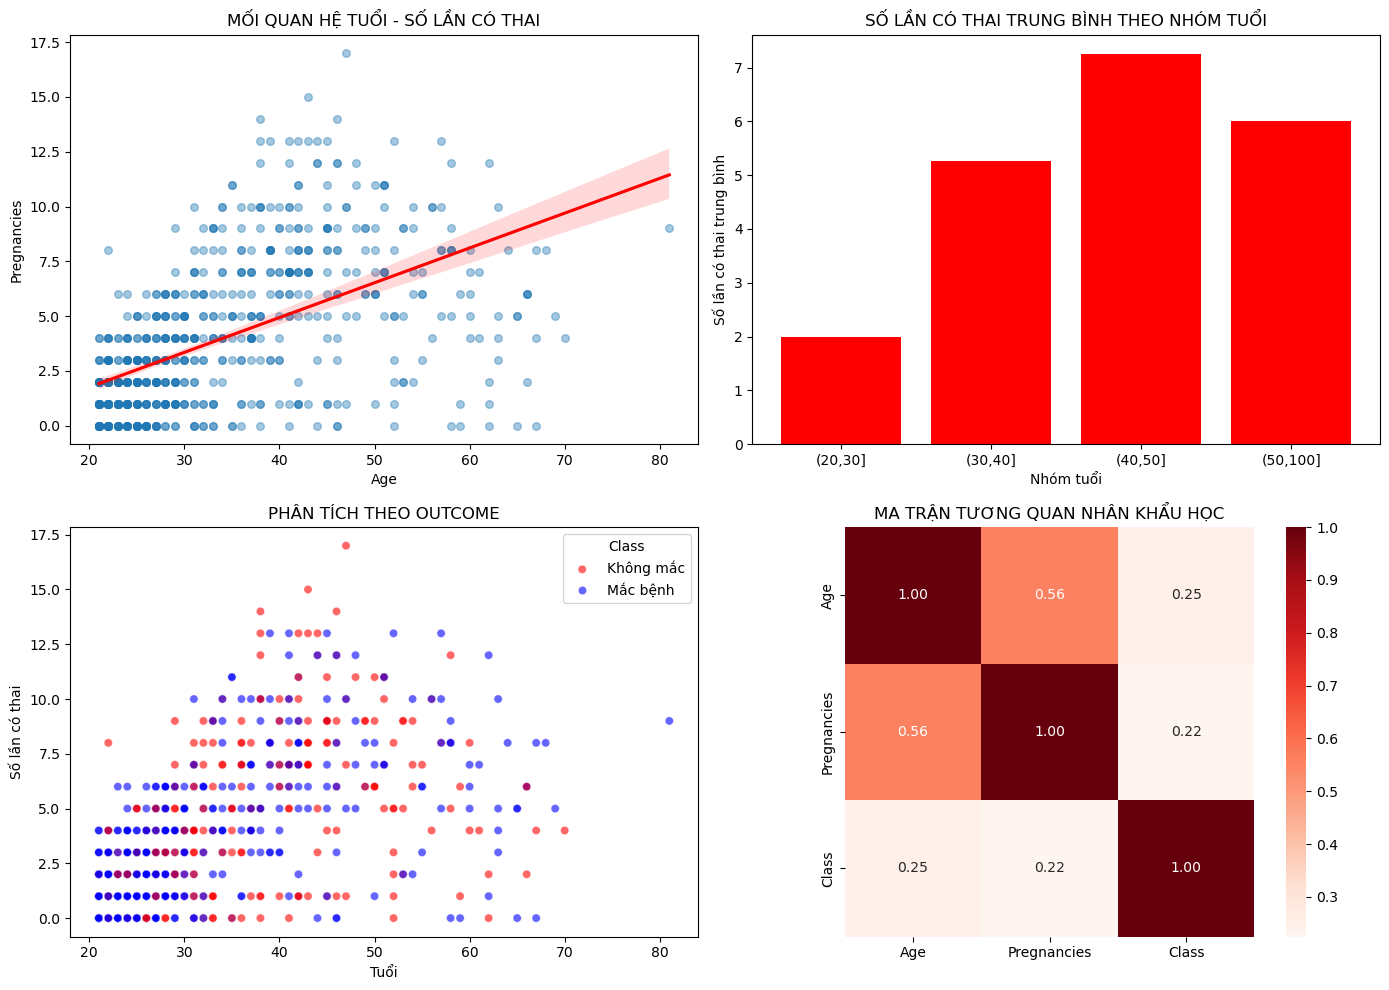

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

##
sns.regplot(
    data=df_dataset,
    x="Age",
    y="Pregnancies",
    scatter_kws={"alpha": 0.4, "s": 30},
    line_kws={"color": "red"},
    ax=axes[0, 0]
)

axes[0, 0].set_title("MỐI QUAN HỆ TUỔI - SỐ LẦN CÓ THAI")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Pregnancies")

##
# Chia nhóm tuổi
bins = [20, 30, 40, 50, 100]
labels = ["(20,30]", "(30,40]", "(40,50]", "(50,100]"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

avg_preg = df_dataset.groupby("AgeGroup")["Pregnancies"].mean()

axes[0, 1].bar(
    avg_preg.index.astype(str),
    avg_preg.values,
    color="red"
)

axes[0, 1].set_title("SỐ LẦN CÓ THAI TRUNG BÌNH THEO NHÓM TUỔI")
axes[0, 1].set_xlabel("Nhóm tuổi")
axes[0, 1].set_ylabel("Số lần có thai trung bình")
##
sns.scatterplot(
    data=df_dataset,
    x="Age",
    y="Pregnancies",
    hue="Class",
    palette={0: "blue", 1: "red"},
    alpha=0.6,
    ax=axes[1, 0]
)

axes[1, 0].set_title("PHÂN TÍCH THEO OUTCOME")
axes[1, 0].set_xlabel("Tuổi")
axes[1, 0].set_ylabel("Số lần có thai")
axes[1, 0].legend(title="Class", labels=["Không mắc", "Mắc bệnh"])
##
corr_df = df_dataset[["Age", "Pregnancies", "Class"]].corr()

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    square=True,
    ax=axes[1, 1]
)

axes[1, 1].set_title("MA TRẬN TƯƠNG QUAN NHÂN KHẨU HỌC")

plt.tight_layout()
plt.savefig(
    "hinh_5_4_age_pregnancies.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()




In [72]:
from scipy.stats import pearsonr

# Lấy 2 biến cần phân tích
x = df_dataset["Pregnancies"]
y = df_dataset["Age"]

# Tính Pearson correlation
r, p_value = pearsonr(x, y)

print("Hệ số tương quan Pearson r =", round(r, 3))
print("Giá trị p-value =", p_value)

Hệ số tương quan Pearson r = 0.556
Giá trị p-value = 1.0711201453582515e-59


## Ma trận BMI

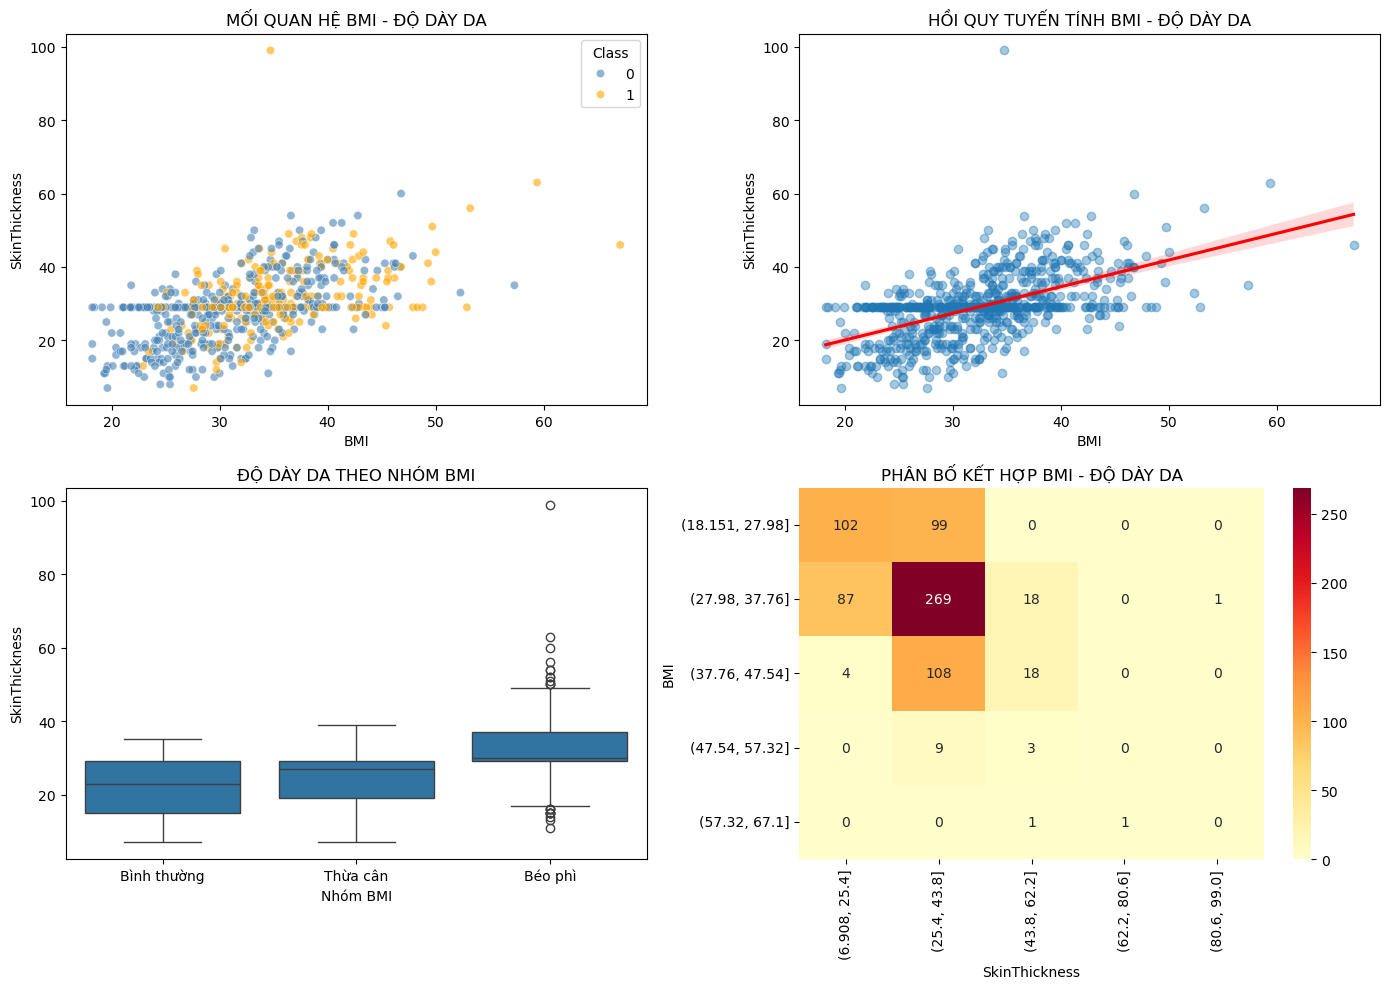

In [73]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
##
sns.scatterplot(
    data=df_dataset,
    x="BMI",
    y="SkinThickness",
    hue="Class",
    palette={0: "steelblue", 1: "orange"},
    alpha=0.6,
    ax=axes[0, 0]
)
axes[0, 0].set_title("MỐI QUAN HỆ BMI - ĐỘ DÀY DA")
axes[0, 0].set_xlabel("BMI")
axes[0, 0].set_ylabel("SkinThickness")
##
sns.regplot(
    data=df_dataset,
    x="BMI",
    y="SkinThickness",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
    ax=axes[0, 1]
)
axes[0, 1].set_title("HỒI QUY TUYẾN TÍNH BMI - ĐỘ DÀY DA")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("SkinThickness")
##
bins = [0, 25, 30, 100]
labels = ["Bình thường", "Thừa cân", "Béo phì"]
df_dataset["BMI_Group"] = pd.cut(df_dataset["BMI"], bins=bins, labels=labels)

sns.boxplot(
    data=df_dataset,
    x="BMI_Group",
    y="SkinThickness",
    ax=axes[1, 0]
)
axes[1, 0].set_title("ĐỘ DÀY DA THEO NHÓM BMI")
axes[1, 0].set_xlabel("Nhóm BMI")
axes[1, 0].set_ylabel("SkinThickness")

##
bmi_bins = pd.cut(df_dataset["BMI"], bins=5)
skin_bins = pd.cut(df_dataset["SkinThickness"], bins=5)
heatmap_data = pd.crosstab(bmi_bins, skin_bins)

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    ax=axes[1, 1]
)
axes[1, 1].set_title("PHÂN BỐ KẾT HỢP BMI - ĐỘ DÀY DA")
axes[1, 1].set_xlabel("SkinThickness")
axes[1, 1].set_ylabel("BMI")
##
plt.tight_layout()
plt.savefig("Hinh_5_3_BMI_SkinThickness.png", dpi=300)
plt.show()



In [74]:
from scipy.stats import pearsonr

# Lấy 2 biến cần phân tích
x = df_dataset["BMI"]
y = df_dataset["SkinThickness"]

# Tính Pearson correlation
r, p_value = pearsonr(x, y)

print("Hệ số tương quan Pearson r =", round(r, 3))
print("Giá trị p-value =", p_value)

Hệ số tương quan Pearson r = 0.551
Giá trị p-value = 1.7940916735376755e-58


##  Glucose - Insulin

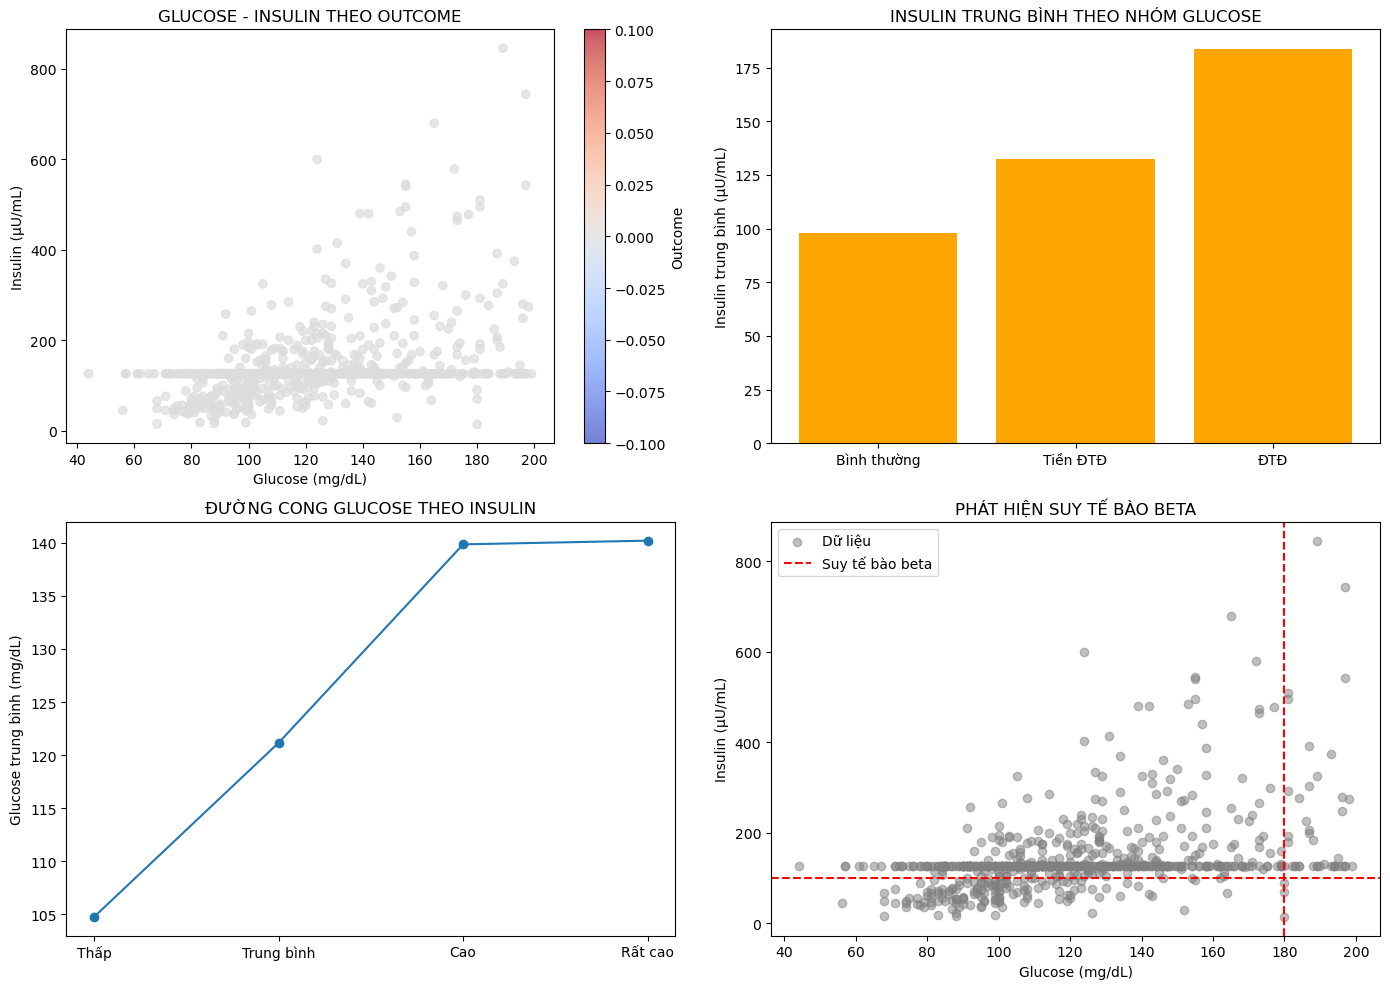

In [105]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df_gi = df_dataset[df_dataset["Insulin"] > 0]

##
sc = axes[0, 0].scatter(
    df_gi["Glucose"],
    df_gi["Insulin"],
    c=df_gi["Class"],
    cmap="coolwarm",
    alpha=0.7
)
axes[0, 0].set_title("GLUCOSE - INSULIN THEO OUTCOME")
axes[0, 0].set_xlabel("Glucose (mg/dL)")
axes[0, 0].set_ylabel("Insulin (µU/mL)")
plt.colorbar(sc, ax=axes[0, 0], label="Outcome")

##

glucose_bins = [0, 100, 126, 200]
glucose_labels = ["Bình thường", "Tiền ĐTĐ", "ĐTĐ"]
df_gi["Glucose_Group"] = pd.cut(df_gi["Glucose"], bins=glucose_bins, labels=glucose_labels)

mean_insulin = df_gi.groupby("Glucose_Group")["Insulin"].mean()

axes[0, 1].bar(mean_insulin.index, mean_insulin.values, color="orange")
axes[0, 1].set_title("INSULIN TRUNG BÌNH THEO NHÓM GLUCOSE")
axes[0, 1].set_ylabel("Insulin trung bình (µU/mL)")
##

insulin_bins = pd.qcut(df_gi["Insulin"], q=4, labels=["Thấp", "Trung bình", "Cao", "Rất cao"])
glucose_mean = df_gi.groupby(insulin_bins)["Glucose"].mean()

axes[1, 0].plot(glucose_mean.index, glucose_mean.values, marker="o")
axes[1, 0].set_title("ĐƯỜNG CONG GLUCOSE THEO INSULIN")
axes[1, 0].set_ylabel("Glucose trung bình (mg/dL)")


##

axes[1, 1].scatter(
    df_gi["Glucose"],
    df_gi["Insulin"],
    color="gray",
    alpha=0.5,
    label="Dữ liệu"
)

# Ngưỡng y học
axes[1, 1].axvline(180, color="red", linestyle="--")
axes[1, 1].axhline(100, color="red", linestyle="--", label="Suy tế bào beta")

axes[1, 1].set_title("PHÁT HIỆN SUY TẾ BÀO BETA")
axes[1, 1].set_xlabel("Glucose (mg/dL)")
axes[1, 1].set_ylabel("Insulin (µU/mL)")
axes[1, 1].legend()
##

plt.tight_layout()
plt.savefig("Hinh_5_5_Glucose_Insulin.png", dpi=300)
plt.show()




In [104]:
from scipy.stats import pearsonr

# Lấy 2 biến cần phân tích
x = df_dataset["Glucose"]
y = df_dataset["Insulin"]

# Tính Pearson correlation
r, p_value = pearsonr(x, y)

print("Hệ số tương quan Pearson r =", round(r, 3))
print("Giá trị p-value =", p_value)

df_valid = df_dataset[df_dataset["Insulin"] > 0]

r, p_value = pearsonr(df_valid["Glucose"], df_valid["Insulin"])
print("r =", round(r, 3))


Hệ số tương quan Pearson r = 0.425
Giá trị p-value = 5.190961204893348e-33
r = 0.425


In [115]:
df_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Class
0,6.0,148.0,72.0,35,126,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29,126,26.6,0.351,31.0,0
2,8.0,183.0,64.0,29,126,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23,94,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35,168,43.1,2.288,33.0,1


# Sử lí

In [16]:
# =========================
# 1. COPY DATASET GỐC
# =========================
df_dataset2 = df_dataset.copy()

# =========================
# 2. ÉP TOÀN BỘ SANG FLOAT
# =========================
df_dataset2 = df_dataset2.apply(pd.to_numeric, errors='coerce')

# =========================
# 3. XỬ LÝ GIÁ TRỊ 0 BẤT HỢP LÝ
# (Chuẩn dataset Pima)
# =========================
# cols_with_zero_invalid = [
#     "Glucose",
#     "BloodPressure",
#     "SkinThickness",
#     "Insulin",
#     "BMI"
# ]

# df_dataset2[cols_with_zero_invalid] = df_dataset2[cols_with_zero_invalid].replace(0, np.nan)

# =========================
# 4. XỬ LÝ NaN (Điền median)
# =========================
df_dataset2.fillna(df_dataset2.median(), inplace=True)

C-SQUARE

       Đặc trưng  Random Forest Importance
0        Glucose                  0.256314
1            BMI                  0.153365
2            Age                  0.137297
3            DPF                  0.127083
4        Insulin                  0.087680
5  BloodPressure                  0.086238
6    Pregnancies                  0.079492
7  SkinThickness                  0.072531


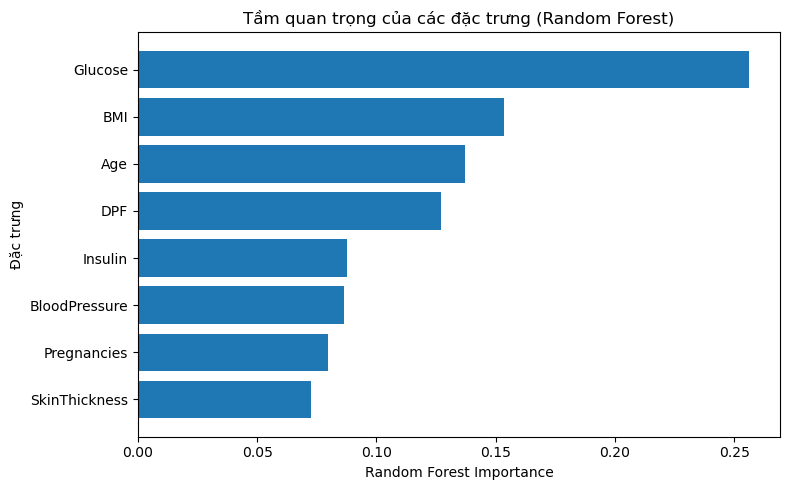

In [15]:

# =========================
# 5. TÁCH X VÀ y
# =========================
X = df_dataset2.drop("Class", axis=1)
y = df_dataset2["Class"]

# =========================
# 6. TRAIN RANDOM FOREST
# =========================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X, y)

# =========================
# 7. FEATURE IMPORTANCE
# =========================
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Đặc trưng": X.columns,
    "Random Forest Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Random Forest Importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance_df.to_string(index=True, float_format="%.6f"))

# =========================
# 8. VẼ BIỂU ĐỒ
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_df["Đặc trưng"],
    feature_importance_df["Random Forest Importance"]
)

plt.xlabel("Random Forest Importance")
plt.ylabel("Đặc trưng")
plt.title("Tầm quan trọng của các đặc trưng (Random Forest)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

       Đặc trưng  Chi-square  p-value
0        Glucose     13.5488   0.0002
1            Age      8.1356   0.0043
2    Pregnancies      6.2175   0.0126
3            BMI      4.2410   0.0395
4            DPF      2.9204   0.0875
5        Insulin      2.3676   0.1239
6  SkinThickness      1.3076   0.2528
7  BloodPressure      1.1069   0.2928


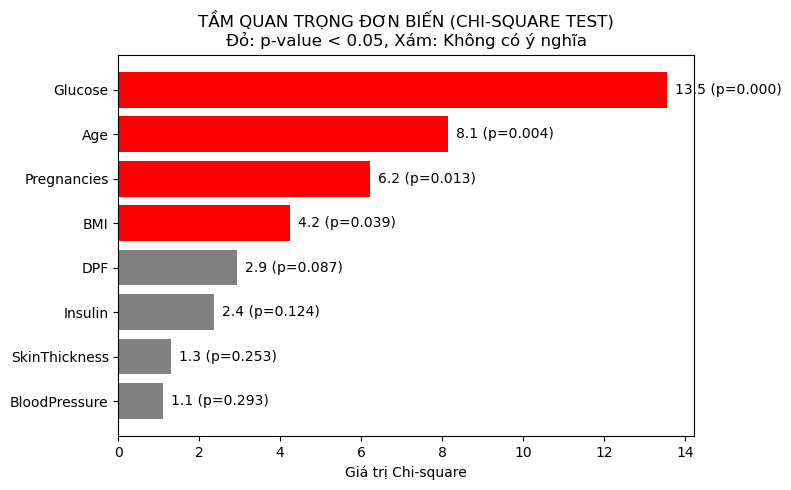

In [10]:
# =========================
# 1. TÁCH X VÀ y
# =========================
X = df_dataset2.drop("Class", axis=1)
y = df_dataset2["Class"]

# =========================
# 2. CHI-SQUARE
# =========================
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Chi2 yêu cầu dữ liệu không âm → scale về [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi_scores, p_values = chi2(X_scaled, y)

# =========================
# 3. TẠO BẢNG KẾT QUẢ
# =========================
chi_square_df = pd.DataFrame({
    "Đặc trưng": X.columns,
    "Chi-square": chi_scores,
    "p-value": p_values
})

# Sắp xếp giảm dần theo Chi-square
chi_square_df = chi_square_df.sort_values(
    by="Chi-square",
    ascending=False
).reset_index(drop=True)

# In giống hình (6 chữ số thập phân)
print(chi_square_df.to_string(index=True, float_format="%.4f"))

##
# =========================
# 1. Giả sử bạn đã có chi_square_df
# (Đặc trưng, Chi-square, p-value)
# =========================

import matplotlib.pyplot as plt
import numpy as np

# Sắp xếp lại cho chắc
chi_square_df = chi_square_df.sort_values(
    by="Chi-square",
    ascending=False
).reset_index(drop=True)

# =========================
# 2. Tạo màu theo p-value
# =========================
colors = [
    "red" if p < 0.05 else "gray"
    for p in chi_square_df["p-value"]
]

# =========================
# 3. Vẽ biểu đồ
# =========================
plt.figure(figsize=(8, 5))

bars = plt.barh(
    chi_square_df["Đặc trưng"],
    chi_square_df["Chi-square"],
    color=colors
)

plt.xlabel("Giá trị Chi-square")
plt.title("TẦM QUAN TRỌNG ĐƠN BIẾN (CHI-SQUARE TEST)\n"
          "Đỏ: p-value < 0.05, Xám: Không có ý nghĩa")

plt.gca().invert_yaxis()

# =========================
# 4. Ghi giá trị lên thanh
# =========================
for i, (value, pval) in enumerate(
    zip(chi_square_df["Chi-square"], chi_square_df["p-value"])
):
    plt.text(
        value + 0.2,
        i,
        f"{value:.1f} (p={pval:.3f})",
        va='center'
    )

plt.tight_layout()
plt.savefig("CSquare.png", dpi=300)
plt.show()



In [11]:
# =========================
# 1. TÁCH X VÀ y
# =========================
X = df_dataset2.drop("Class", axis=1)
y = df_dataset2["Class"]

# =========================
# 2. TÍNH MUTUAL INFORMATION
# =========================
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

# =========================
# 3. TẠO DATAFRAME KẾT QUẢ
# =========================
mi_df = pd.DataFrame({
    "Đặc trưng": X.columns,
    "Mutual Information": mi_scores
})

# Sắp xếp giảm dần
mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
).reset_index(drop=True)

# In giống hình (6 số thập phân)
print(mi_df.to_string(index=True, float_format="%.6f"))

       Đặc trưng  Mutual Information
0        Glucose            0.128075
1            Age            0.071955
2            BMI            0.053817
3    Pregnancies            0.034545
4        Insulin            0.024909
5            DPF            0.015977
6  BloodPressure            0.001725
7  SkinThickness            0.000000


## Random Forest

       Đặc trưng  Random Forest Importance
0        Glucose                  0.256314
1            BMI                  0.153365
2            Age                  0.137297
3            DPF                  0.127083
4        Insulin                  0.087680
5  BloodPressure                  0.086238
6    Pregnancies                  0.079492
7  SkinThickness                  0.072531


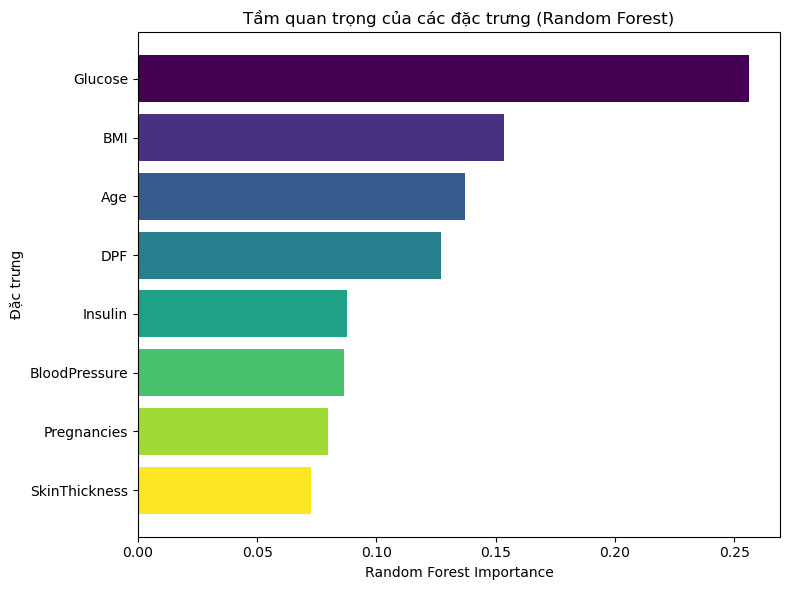

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ==============================
# RANDOM FOREST FEATURE IMPORTANCE
# ==============================

# Tách đặc trưng và nhãn
X = df_dataset2.drop("Class", axis=1)
y = df_dataset2["Class"]

# Khởi tạo mô hình
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Huấn luyện
rf.fit(X, y)

# Lấy độ quan trọng
importances = rf.feature_importances_

# Tạo bảng kết quả
rf_importance_df = pd.DataFrame({
    "Đặc trưng": X.columns,
    "Random Forest Importance": importances
})

# Sắp xếp giảm dần
rf_importance_df = rf_importance_df.sort_values(
    by="Random Forest Importance",
    ascending=False
).reset_index(drop=True)

print(rf_importance_df)

# ==============================
# VẼ BIỂU ĐỒ
# ==============================

colors = plt.cm.viridis(
    np.linspace(0, 1, len(rf_importance_df))
)

plt.figure(figsize=(8,6))

plt.barh(
    rf_importance_df["Đặc trưng"],
    rf_importance_df["Random Forest Importance"],
    color=colors
)

plt.xlabel("Random Forest Importance")
plt.ylabel("Đặc trưng")
plt.title("Tầm quan trọng của các đặc trưng (Random Forest)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("randomf.png", dpi = 300)
plt.show()

### Phát hiện đa cộng tuyến

         Feature    VIF Đánh giá
7            Age  1.649      Tốt
5            BMI  1.633      Tốt
3  SkinThickness  1.469      Tốt
0    Pregnancies  1.454      Tốt
1        Glucose  1.364      Tốt
2  BloodPressure  1.277      Tốt
4        Insulin  1.253      Tốt
6            DPF  1.049      Tốt


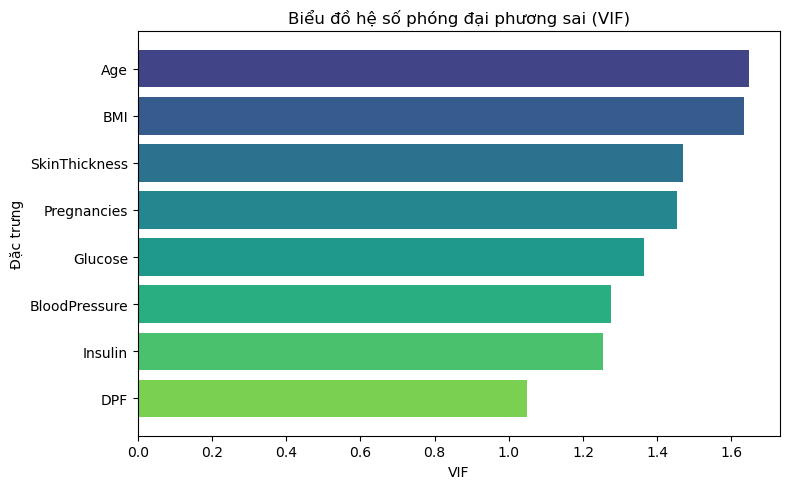

In [19]:
# ===============================
# PHÁT HIỆN ĐA CỘNG TUYẾN (VIF)
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# 1. Tách X (loại Outcome)
X = df_dataset.drop("Class", axis=1)

# 2. Chuẩn hóa dữ liệu (khuyến nghị khi tính VIF)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 3. Tính VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(X_scaled.shape[1])
]

# 4. Đánh giá VIF
def vif_label(v):
    if v < 2:
        return "Tốt"
    elif v < 5:
        return "Trung bình"
    else:
        return "Cao"

vif_data["Đánh giá"] = vif_data["VIF"].apply(vif_label)

# 5. Sắp xếp
vif_data = vif_data.sort_values("VIF", ascending=False)

# 6. In bảng
print(vif_data.round(3))

# 7. Vẽ biểu đồ VIF
plt.figure(figsize=(8,5))
plt.barh(
    vif_data["Feature"],
    vif_data["VIF"],
    color=plt.cm.viridis(np.linspace(0.2, 0.8, len(vif_data)))
)
plt.xlabel("VIF")
plt.ylabel("Đặc trưng")
plt.title("Biểu đồ hệ số phóng đại phương sai (VIF)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("HSPDPS.png", dpi = 300)
plt.show()
